# Underfitting Model

by Niklas Vogel and Kevin Stupar

This notebook creates an underfitting model and evaluates it.
We used the `intel image classfification` data for thrainging out model.

## Steps
- Loading, splitting and inspection fo the data
- Preparing the model and fitting it
- Evaluate the model

## Setup
Before executing this please make sure you did download and extract the data using an unzip tool optimized for your OS (`unzip` in WSL could take a long time)
The Download can be done using `setup.sh`

## Data Credit
- Initially published on https://datahack.analyticsvidhya.com
- Downloaded from https://www.kaggle.com/datasets/puneet6060/intel-image-classification
- Photos by [Jan Böttinger on Unsplash](https://unsplash.com/photos/birds-eye-view-photo-of-building-27xFENkt-lc)

# Loading and splitting the data

The dataset contains six categories: buildings, forest, glacier, mountain, sea and street.
All classes have 2000 samples except street which has only 150.
This is guaranteed by our setup, which deletes excess images.

The dataset is loaded using the "image_dataset_from_directory" method from keras. This method also resizes the images to 64*64 pixels.
Next we shuffle the data using a seed so there is randomness in which go into training, validation and test split.
Using the seed we ensure the splits look the same for all models, but can be changed.

After shuffling we split the data into training, validation and test data.
- training: 56% (80% of non-test)
- validation: 14% (20% of non-test)
- test: 30%

After shuffling we split the data into 3 sections, where the first one is the training and the last one the test data.

In [2]:
from helper import *
from keras import layers, models

image_size = (64, 64)
batch_size = 32

(all_images, train_images, validation_images, test_images, label_names) = get_data(image_size)

Number of training images:  5683
Number of validation images:  1420
Number of testing images:  3045
Class names:  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.
Since we only have 150 streets, we will probably not see them here, but note that the images of streets often include buildings on the side.
This will be important later on.

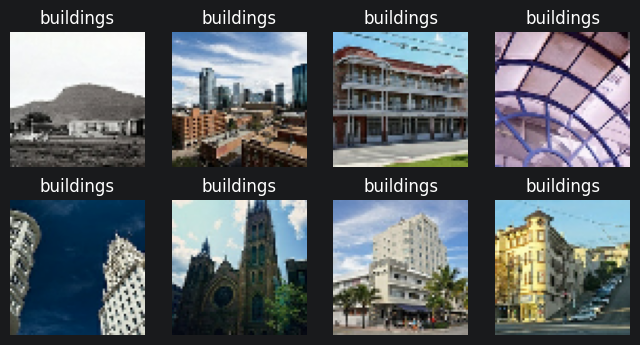

In [3]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 2000 images, except for street, which only has 150 images.

Also we can see that the data is split quite equally over all 3 splits.

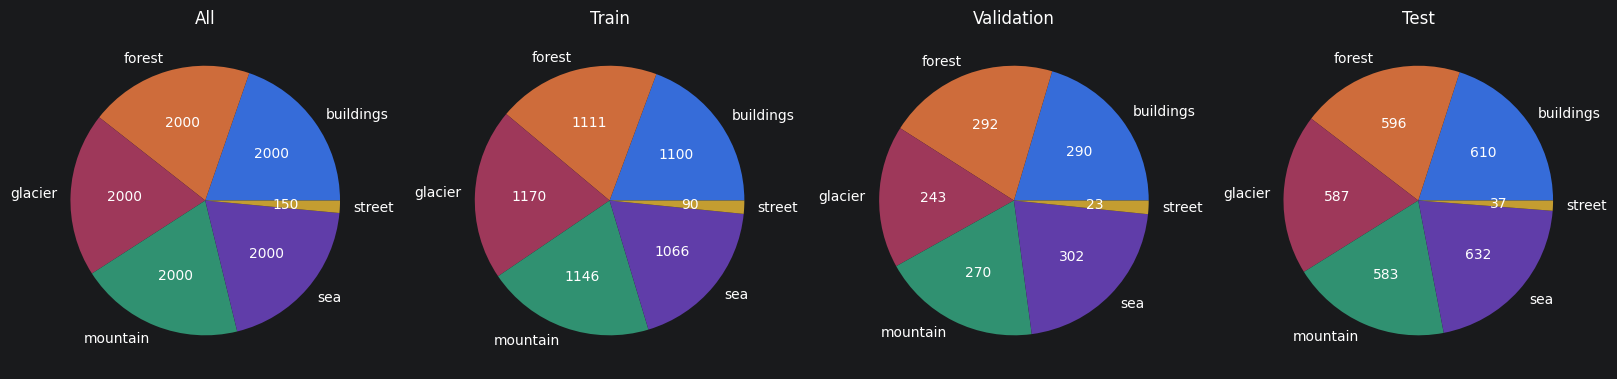

In [4]:
plot_numbers_per_classes({"All": all_images, "Train": train_images, "Validation": validation_images, "Test": test_images}, label_names)

# Building the model

To obtain an underfitting model, the network is intentionally kept small by using only two convolutional layers followed by one dense layer.
We aim at 2000 parameters.

Each layer should learn more abstract features than the previous one, to try to distinguish between the 6 classes.
After each convolutional layer, a MaxPooling operation is applied to reduce the spatial size of the feature maps while preserving the most dominant information effectively shrinking the image. This reduces the trainable parameters as so the models complexity.
The first MaxPooling layer reduces the image size moderately to retain sufficient information for further feature extraction. In contrast, the second MaxPooling layer performs a much stronger reduction, keeping only the most prominent features, to reduce the number of parameters in the dense layer. But before getting to the dense layer the output for the convolutional layers (2D) needs to be flattened after which they are finally sent to the dense layer, which performs the final multi-class classification.

Because the model contains very few trainable parameters, it lacks the capacity to learn complex patterns sticking only to basic features, which should results in underfitting.

Why avoid stride>kernel-size: Strides larger than the kernel size should be avoided otherwise parts of the image would not be used in the compression, causing information loss during feature extraction. Especially when having sharp edges (sky to building) skipping over pixels could be bad.

In [5]:
model = models.Sequential([
    layers.Input(shape=image_size +(3,)),
    layers.Rescaling(1./255),
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(8, (3, 3), activation="relu"),
    layers.MaxPooling2D((8,8)),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           438 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,046 (7.99 KB)

 Trainable params: 2,046 (7.99 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training the model

Here we train the model for 30 epochs.
After some testing we figured 30 epochs are enough to show us the underfitting and also matches with the epochs of the other models.

In [6]:
history = model.fit(train_images.batch(batch_size), epochs=30, validation_data=validation_images.batch(batch_size))

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3790 - loss: 1.4849 - val_accuracy: 0.4901 - val_loss: 1.2224
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5439 - loss: 1.1451 - val_accuracy: 0.5592 - val_loss: 1.0907
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5851 - loss: 1.0524 - val_accuracy: 0.6085 - val_loss: 1.0209
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6155 - loss: 0.9951 - val_accuracy: 0.6296 - val_loss: 0.9649
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6377 - loss: 0.9538 - val_accuracy: 0.6458 - val_loss: 0.9207
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6521 - loss: 0.9231 - val_accuracy: 0.6570 - val_loss: 0.8916
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6634 - loss: 0.8995 - val_accuracy: 0.6697 - val_loss: 0.8691
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6706 - loss: 0.8800 - val_accuracy: 0.

# Evaluating the model

Using a few plots we can see, that the model is underfitting.

Accuracy: 0.7873239436619718
Loss: 0.6486123618374723


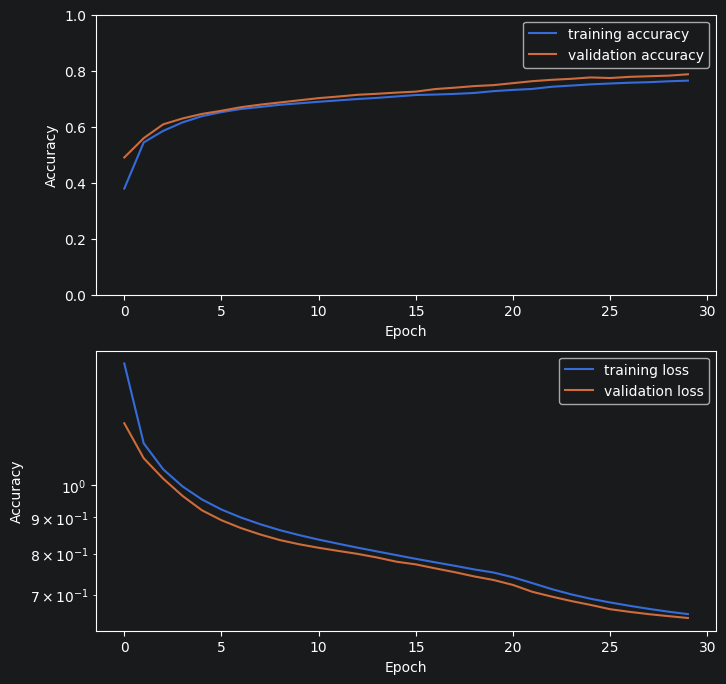

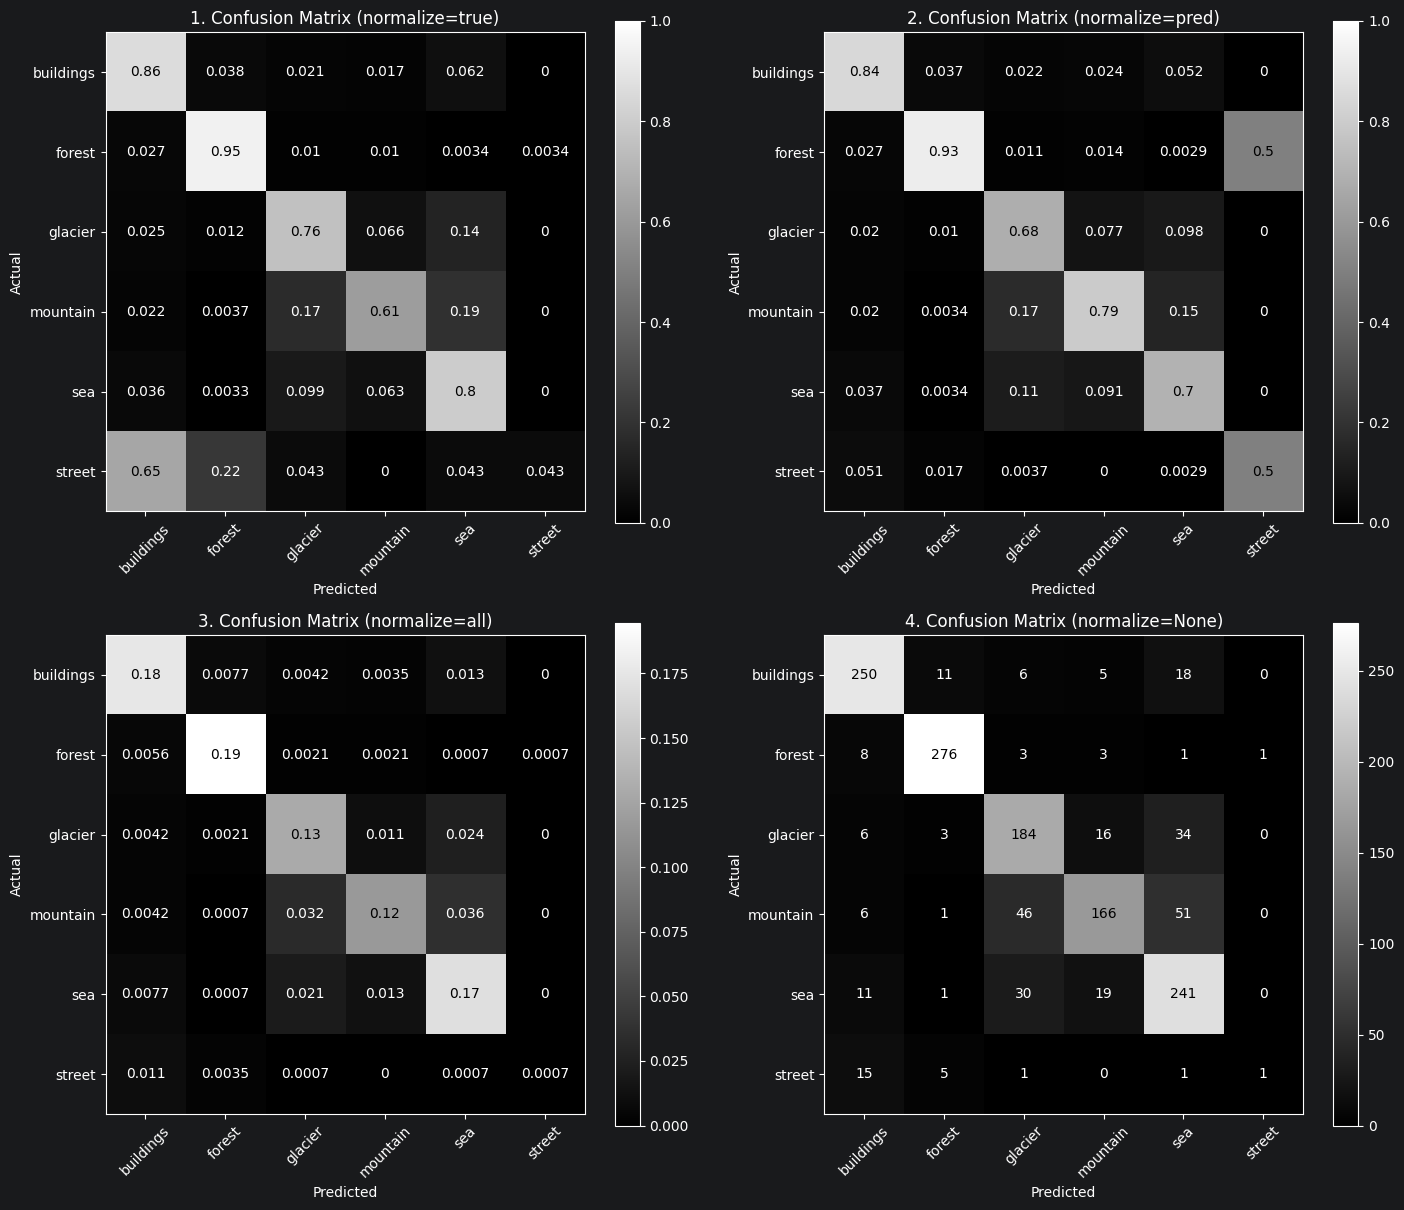

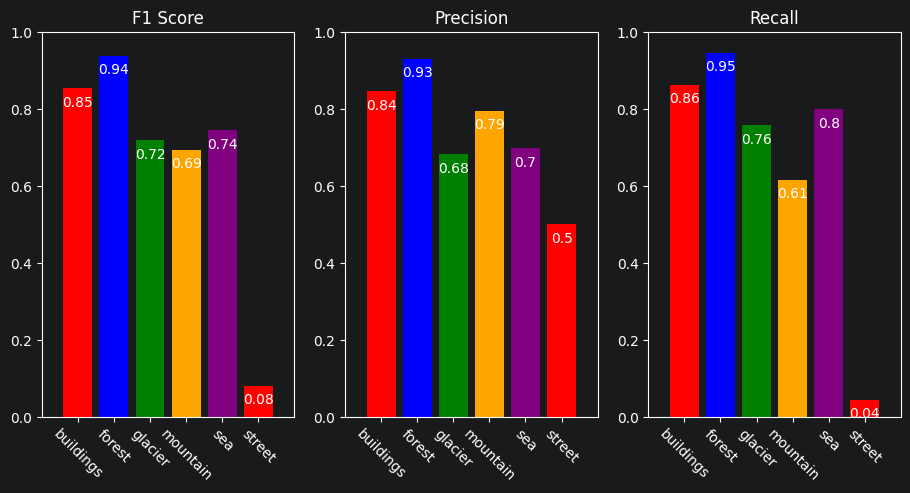

In [7]:
true, pred, pred_raw = calculate_predictions(model, validation_images.batch(batch_size))

print_accuracy_and_loss(true, pred, pred_raw)
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])
plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)

# Discussion
- Overall performance: The model has a training accuracy of about 0.76 and a validation accuracy of about 0.71. Since both values are relatively low the model did not perform good. Also both values are very close to each other which means we have low variance. Low variance + high bias = underfitting.
- Accuracy: The training and validation accuracy follow almost identical learning curve and are quit low which is typical for an underfitting model. This behavior indicates that the model generalizes to much. Most learning happens during the first few epochs, after which the accuracy quickly stagnates, showing that the model only learns simple patterns an can not comprehend complex ones.
- Loss: The loss being quit hingh reflects that our model is not very confident ^with its predictions. Initially, the loss is high because the model starts with random weights, but it decreases rapidly as the model learns. Towards the end of training, both training and validation loss remain relatively high and plateau, which is characteristic of underfitting. The validation loss being slightly higher than the training loss tells us that performance on unseen data is worse.
- Confusion Metrix:
  1. This is the recall matrix we can see the recall for each class combination. For example we can see that 66% of street samples got predicted as buildings by the model.
  2. This is the precision matrix. This tells us what happened when the model predicted a class. So the model predicted street and in 80% of cases it also was street but in 20% of cases it actuly was a building.
  3. This matrix shows wich classes dominated the models performance. So we can see that 18% of all samples were correctly classified as forest. This is quit usefully. If we look at the training metrix below we see that glacier did not performe so good. But looking at the matrix we see that 15% of all images were correctly classified as glaciers (glacier makes up about 20% of the samples).
  4. This is the same as 3 but the matrix does not add up to 1 instead it adds up to the number of samples in the dataset. This is great for seeing imbalances in the dataset. We can see that there are very vew street samples.
- Training metrics
    - F1 score: This tells us how balanced our model is, wich is not very balanced there are very little street samples. This is not surprising because we only have 150 street samples.
    - Precision: Precision measures how many of the samples predicted as a given class are actually of that class. And here somthing surprising happens. The street class with only 150 samples seams to get predicted better then most other classes. But this is misleading and explained by the recall.
    - Recall: The recall tells us that only a tiny amount of streets even get classified as such. So the model only predicts street if it is really confident, which explains the high precision. The recall also nicely shows the high bias of an underfitting model, by only seldon predicting street.

From both confusion matrix and training metrics we see that given the simplicity of the model it still learned the forest class quite well. This is probably due to forest beeing very different to all other classes.

